<a href="https://colab.research.google.com/github/yuvrajsinghsekhawat24-bot/breast-cancer--prediction/blob/main/Breast_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Breast Cancer Prediction Using Machine Learning

## Internship Project

### Developed By:
**Yuvraj Singh**

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

---

## Project Objective

The objective of this project is to develop a machine learning model that predicts whether a breast tumor is **Benign** or **Malignant** based on diagnostic features. Multiple machine learning algorithms are trained and compared to identify the most accurate model.

> **Disclaimer:** This project is developed for educational purposes only and should not be used as a substitute for professional medical diagnosis.

In [ ]:
# =====================================
# Import Required Libraries
# =====================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
# =====================================
# Load Breast Cancer Dataset
# =====================================

cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add target column
df["target"] = cancer.target

print("Dataset Loaded Successfully!")
print()

print("Shape of Dataset:", df.shape)

df.head()

Dataset Loaded Successfully!

Shape of Dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# =====================================
# Dataset Information
# =====================================

print("Dataset Information")
print("-" * 40)

df.info()

Dataset Information
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error         

In [ ]:
# =====================================
# Statistical Summary
# =====================================

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
# =====================================
# Check Missing Values
# =====================================

print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [ ]:
# =====================================
# Target Class Distribution
# =====================================

print(df["target"].value_counts())

print("\n0 = Malignant")
print("1 = Benign")

target
1    357
0    212
Name: count, dtype: int64

0 = Malignant
1 = Benign


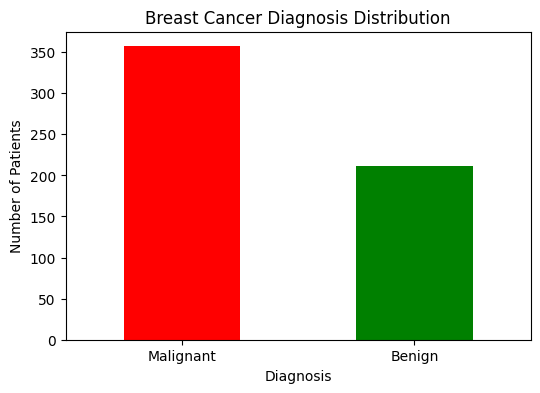

In [ ]:
# =====================================
# Visualize Target Distribution
# =====================================

plt.figure(figsize=(6,4))

df['target'].value_counts().plot(
    kind='bar',
    color=['red', 'green']
)

plt.title("Breast Cancer Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["Malignant", "Benign"], rotation=0)

plt.show()


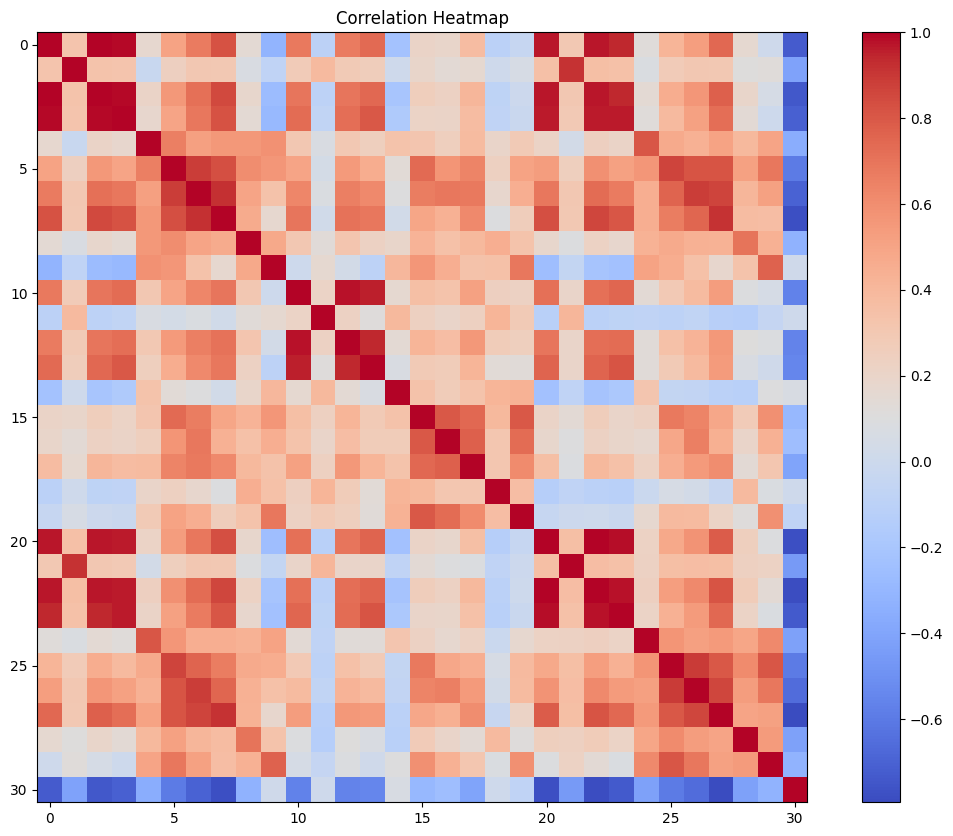

In [ ]:
# =====================================
# Correlation Heatmap
# =====================================

plt.figure(figsize=(14,10))

correlation = df.corr()

plt.imshow(correlation, cmap='coolwarm')

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

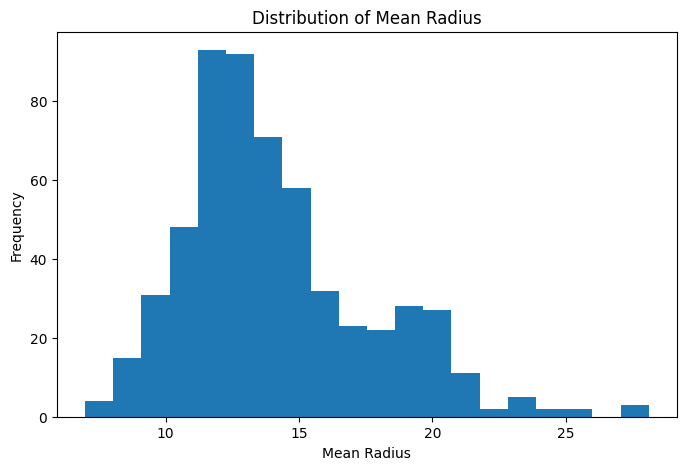

In [ ]:
# =====================================
# Histogram
# =====================================

plt.figure(figsize=(8,5))

plt.hist(df['mean radius'], bins=20)

plt.title("Distribution of Mean Radius")

plt.xlabel("Mean Radius")

plt.ylabel("Frequency")

plt.show()

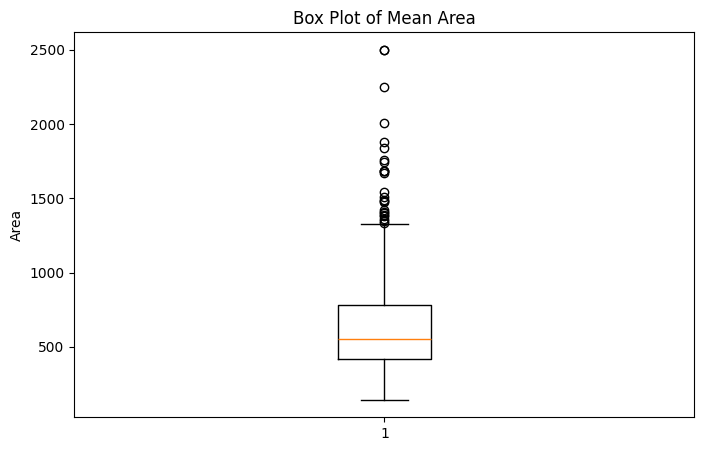

In [ ]:
# =====================================
# Box Plot
# =====================================

plt.figure(figsize=(8,5))

plt.boxplot(df['mean area'])

plt.title("Box Plot of Mean Area")

plt.ylabel("Area")

plt.show()


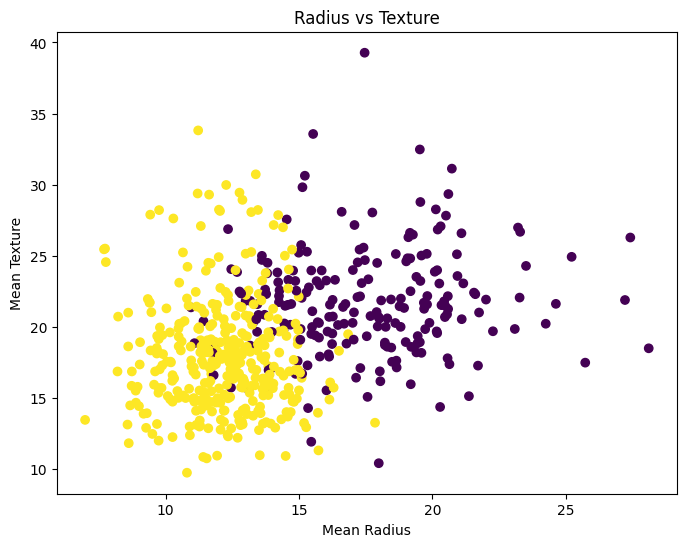

In [ ]:
# =====================================
# Scatter Plot
# =====================================

plt.figure(figsize=(8,6))

plt.scatter(
    df['mean radius'],
    df['mean texture'],
    c=df['target']
)

plt.title("Radius vs Texture")

plt.xlabel("Mean Radius")

plt.ylabel("Mean Texture")

plt.show()

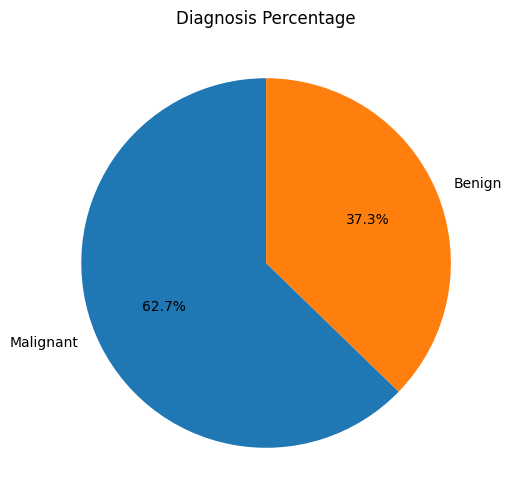

In [ ]:
# =====================================
# Pie Chart
# =====================================

labels = ["Malignant", "Benign"]

sizes = df['target'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Diagnosis Percentage")

plt.show()

In [ ]:
# =====================================
# Separate Features and Target
# =====================================

X = df.drop('target', axis=1)
y = df['target']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (569, 30)
Target Shape : (569,)


In [ ]:
# =====================================
# Train-Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (455, 30)
Testing Data : (114, 30)


In [ ]:
# =====================================
# Feature Scaling
# =====================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [ ]:
# =====================================
# Logistic Regression
# =====================================

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_accuracy*100,2),"%")

Logistic Regression Accuracy : 97.37 %


In [ ]:
# =====================================
# Decision Tree
# =====================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2),"%")

Decision Tree Accuracy : 94.74 %


In [ ]:
# =====================================
# KNN
# =====================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", round(knn_accuracy*100,2),"%")

KNN Accuracy : 94.74 %


In [ ]:
# =====================================
# Random Forest
# =====================================

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_accuracy*100,2),"%")

Random Forest Accuracy : 96.49 %


In [ ]:
# =====================================
# Model Comparison
# =====================================

results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'KNN',
        'Random Forest'
    ],
    'Accuracy (%)':[
        lr_accuracy*100,
        dt_accuracy*100,
        knn_accuracy*100,
        rf_accuracy*100
    ]
})

results = results.sort_values(
    by='Accuracy (%)',
    ascending=False
)

results

,Model,Accuracy (%)
0,Logistic Regression,97.368421
3,Random Forest,96.491228
1,Decision Tree,94.736842
2,KNN,94.736842


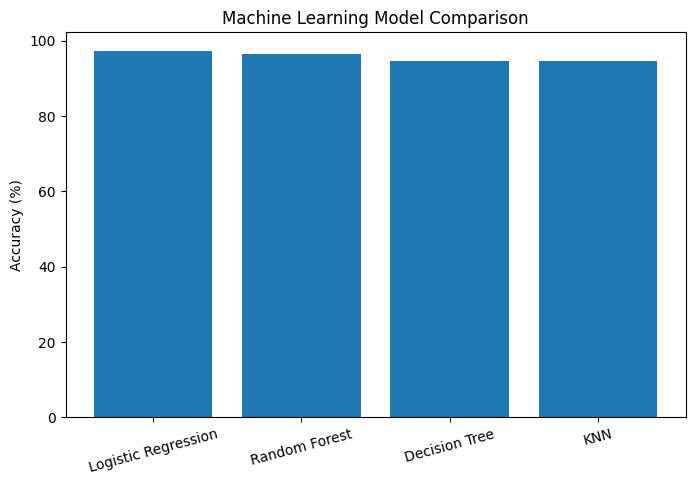

In [ ]:
# =====================================
# Accuracy Comparison
# =====================================

plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Accuracy (%)'])

plt.title("Machine Learning Model Comparison")

plt.ylabel("Accuracy (%)")

plt.xticks(rotation=15)

plt.show()

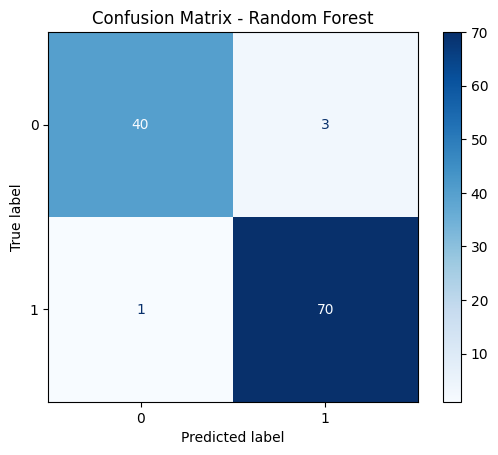

In [ ]:
# =====================================
# Confusion Matrix
# =====================================

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Random Forest")

plt.show()

In [ ]:
# =====================================
# Classification Report
# =====================================

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
# =====================================
# Feature Importance
# =====================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001
22,worst perimeter,0.067115
2,mean perimeter,0.053270
0,mean radius,0.048703
3,mean area,0.047555
26,worst concavity,0.031802


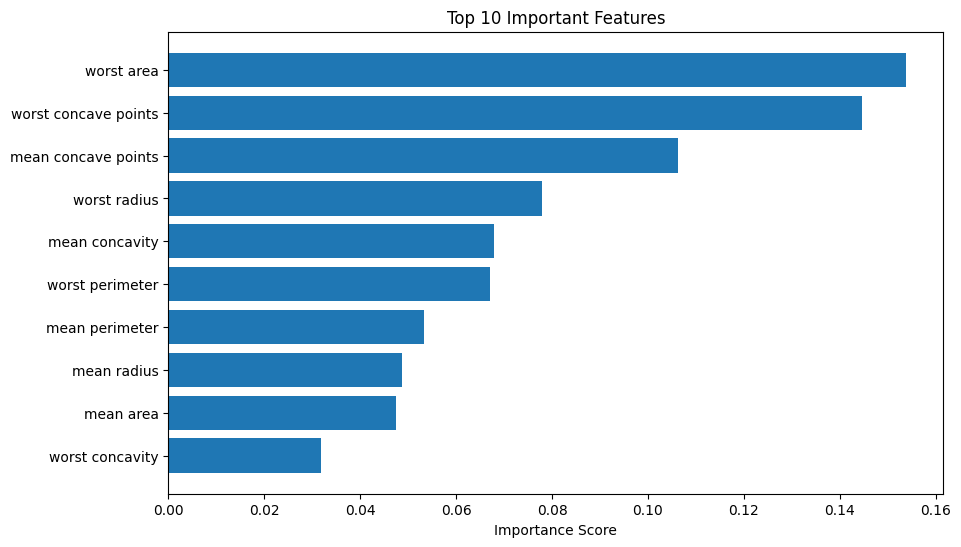

In [ ]:
# =====================================
# Top 10 Features
# =====================================

top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10['Feature'], top10['Importance'])

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# =====================================
# Predict First Test Patient
# =====================================

sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)

probability = rf.predict_proba(sample)

print("="*50)

if prediction[0] == 1:
    print("Prediction : BENIGN")
else:
    print("Prediction : MALIGNANT")

print()

print("Confidence :", round(max(probability[0])*100,2), "%")

print("="*50)

Prediction : BENIGN

Confidence : 97.0 %


In [ ]:
# =====================================
# Actual vs Predicted
# =====================================

actual = y_test.iloc[0]

print("Actual Diagnosis :", "Benign" if actual==1 else "Malignant")

print("Predicted Diagnosis :", "Benign" if prediction[0]==1 else "Malignant")

Actual Diagnosis : Benign
Predicted Diagnosis : Benign


In [ ]:
# =====================================
# Predict First Five Patients
# =====================================

predictions = rf.predict(X_test[:5])

for i in range(5):

    print("="*40)

    print("Patient", i+1)

    print("Actual :", "Benign" if y_test.iloc[i]==1 else "Malignant")

    print("Predicted :", "Benign" if predictions[i]==1 else "Malignant")

print("="*40)

Patient 1
Actual : Benign
Predicted : Benign
Patient 2
Actual : Malignant
Predicted : Malignant
Patient 3
Actual : Malignant
Predicted : Malignant
Patient 4
Actual : Benign
Predicted : Benign
Patient 5
Actual : Benign
Predicted : Benign


In [ ]:
results_df = pd.DataFrame({
    "Actual": ["Benign" if x == 1 else "Malignant" for x in y_test[:10]],
    "Predicted": ["Benign" if x == 1 else "Malignant" for x in rf_pred[:10]]
})

results_df

,Actual,Predicted
0,Benign,Benign
1,Malignant,Malignant
2,Malignant,Malignant
3,Benign,Benign
4,Benign,Benign
5,Malignant,Malignant
6,Malignant,Malignant
7,Malignant,Malignant
8,Benign,Malignant
9,Benign,Benign


In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

# Prediction Function
def predict_cancer(*features):
    # Convert input to DataFrame
    input_df = pd.DataFrame([features], columns=X.columns)

    # Scale the input
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = rf.predict(input_scaled)[0]
    probability = rf.predict_proba(input_scaled)[0]

    confidence = round(max(probability) * 100, 2)

    if prediction == 1:
        result = f"✅ Benign\nConfidence: {confidence}%"
    else:
        result = f"⚠️ Malignant\nConfidence: {confidence}%"

    return result

In [ ]:
inputs = [
    gr.Number(label=feature)
    for feature in X.columns
]

interface = gr.Interface(
    fn=predict_cancer,
    inputs=inputs,
    outputs="text",
    title="🩺 Breast Cancer Prediction System",
    description="Enter the patient's diagnostic values to predict whether the tumor is Benign or Malignant."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a184d54ce44dcdf690.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion

In this project, multiple machine learning algorithms were trained to predict whether a breast tumor is benign or malignant. After comparing the models, Random Forest achieved the highest accuracy and was selected for the final prediction system. This project demonstrates how machine learning can assist in disease prediction while emphasizing that the results are intended for educational purposes only and should not replace professional medical advice.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", round(grid.best_score_*100,2), "%")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross Validation Accuracy: 96.26 %


In [ ]:
best_rf = grid.best_estimator_

best_rf.fit(X_train, y_train)

best_pred = best_rf.predict(X_test)

print("Test Accuracy:",
      round(accuracy_score(y_test, best_pred)*100,2), "%")

Test Accuracy: 96.49 %


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage CV Accuracy:",
      round(scores.mean()*100,2), "%")

Cross Validation Scores:
[0.97802198 0.94505495 0.97802198 0.95604396 0.95604396]

Average CV Accuracy: 96.26 %


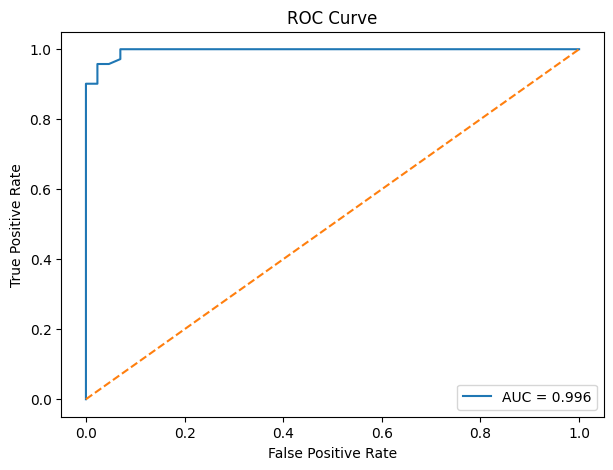

ROC AUC Score: 0.996


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

probabilities = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probabilities)

auc = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC AUC Score:", round(auc,3))

In [ ]:
import joblib

joblib.dump(best_rf, "breast_cancer_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
print("="*60)
print(" Breast Cancer Prediction Project Completed Successfully ")
print("="*60)

print("""
Project Summary
-----------------------
✓ Data Loaded
✓ Data Explored
✓ Data Visualized
✓ Data Preprocessed
✓ Models Trained
✓ Best Model Selected
✓ Hyperparameter Tuning Completed
✓ Cross Validation Completed
✓ ROC Curve Generated
✓ Prediction System Created
✓ Model Saved

Thank You!
""")

 Breast Cancer Prediction Project Completed Successfully 

Project Summary
-----------------------
✓ Data Loaded
✓ Data Explored
✓ Data Visualized
✓ Data Preprocessed
✓ Models Trained
✓ Best Model Selected
✓ Hyperparameter Tuning Completed
✓ Cross Validation Completed
✓ ROC Curve Generated
✓ Prediction System Created
✓ Model Saved

Thank You!

